In [109]:
!pip install Pandas
!pip install Numpy
!pip install matplotlib 
!pip install plotly 
!pip install seaborn  
!pip install  scikit-learn  


#  Customer Churn Analysis (EDA)

## Objective
To analyze customer behavior and identify key factors driving churn using exploratory data analysis (EDA).


In [110]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# Data Cleaning

## Objective
Ensure data quality by handling missing values, correcting inconsistencies, and preparing features for reliable analysis.


##  Steps Performed

### 1. Handling Missing Values
- Numerical columns (e.g., `Age`, `Session_Duration_Avg`) → filled using **median** to reduce impact of outliers  
- Behavioral metrics (e.g., `Pages_Per_Session`) → filled using **mean** where distribution was stable  
- Certain fields (e.g., discount usage, returns) were interpreted contextually before imputation



### 2. Outlier Treatment
- Identified unrealistic values (e.g., Age < 18 or > 100)  
- Replaced with `NaN` and imputed using median


### 3. Data Type Corrections
- Converted categorical columns (e.g., `Gender`, `Country`) to **category dtype**  
- Ensured numerical fields were properly stored as `float64` or `int64`


### 4. Feature Engineering
- Created meaningful groups using binning:
  - `login_freq_Group`
  - `purchase_group`
  - `service_group`
- These helped in better segmentation and analysis



### 5. Data Consistency
- Removed/merged sparse or unreliable categories  
- Ensured balanced group distributions for accurate insights





In [111]:


df = pd.read_csv(
    r"D:\data analytics\personal project\raw dataset\ecommerce_customer_churn_dataset.csv")



In [112]:
df.head()

,Age,Gender,Country,City,Membership_Years,Login_Frequency,Session_Duration_Avg,Pages_Per_Session,Cart_Abandonment_Rate,Wishlist_Items,...,Email_Open_Rate,Customer_Service_Calls,Product_Reviews_Written,Social_Media_Engagement_Score,Mobile_App_Usage,Payment_Method_Diversity,Lifetime_Value,Credit_Balance,Churned,Signup_Quarter
0,43.0,Male,France,Marseille,2.9,14.0,27.4,6.0,50.6,3.0,...,17.9,9.0,4.0,16.3,20.8,1.0,953.33,2278.0,0,Q1
1,36.0,Male,UK,Manchester,1.6,15.0,42.7,10.3,37.7,1.0,...,42.8,7.0,3.0,NaN,23.3,3.0,1067.47,3028.0,0,Q4
2,45.0,Female,Canada,Vancouver,2.9,10.0,24.8,1.6,70.9,1.0,...,0.0,4.0,1.0,NaN,8.8,NaN,1289.75,2317.0,0,Q4
3,56.0,Female,USA,New York,2.6,10.0,38.4,14.8,41.7,9.0,...,41.4,2.0,5.0,85.9,31.0,3.0,2340.92,2674.0,0,Q1
4,35.0,Male,India,Delhi,3.1,29.0,51.4,NaN,19.1,9.0,...,37.9,1.0,11.0,83.0,50.4,4.0,3041.29,5354.0,0,Q4


In [113]:
print("Rows, Columns:", df.shape)

df.columns.tolist()

Rows, Columns: (50000, 25)


['Age',
 'Gender',
 'Country',
 'City',
 'Membership_Years',
 'Login_Frequency',
 'Session_Duration_Avg',
 'Pages_Per_Session',
 'Cart_Abandonment_Rate',
 'Wishlist_Items',
 'Total_Purchases',
 'Average_Order_Value',
 'Days_Since_Last_Purchase',
 'Discount_Usage_Rate',
 'Returns_Rate',
 'Email_Open_Rate',
 'Customer_Service_Calls',
 'Product_Reviews_Written',
 'Social_Media_Engagement_Score',
 'Mobile_App_Usage',
 'Payment_Method_Diversity',
 'Lifetime_Value',
 'Credit_Balance',
 'Churned',
 'Signup_Quarter']

In [114]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 25 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Age                            47505 non-null  float64
 1   Gender                         50000 non-null  object 
 2   Country                        50000 non-null  object 
 3   City                           50000 non-null  object 
 4   Membership_Years               50000 non-null  float64
 5   Login_Frequency                50000 non-null  float64
 6   Session_Duration_Avg           46601 non-null  float64
 7   Pages_Per_Session              47000 non-null  float64
 8   Cart_Abandonment_Rate          50000 non-null  float64
 9   Wishlist_Items                 46000 non-null  float64
 10  Total_Purchases                50000 non-null  float64
 11  Average_Order_Value            50000 non-null  float64
 12  Days_Since_Last_Purchase       47000 non-null 

In [115]:
df['Age'].unique

<bound method Series.unique of 0        43.0
1        36.0
2        45.0
3        56.0
4        35.0
         ... 
49995    38.0
49996    37.0
49997    44.0
49998    41.0
49999    56.0
Name: Age, Length: 50000, dtype: float64>

In [116]:
df[(df['Age'] < 0) | (df['Age'] > 100)]

,Age,Gender,Country,City,Membership_Years,Login_Frequency,Session_Duration_Avg,Pages_Per_Session,Cart_Abandonment_Rate,Wishlist_Items,...,Email_Open_Rate,Customer_Service_Calls,Product_Reviews_Written,Social_Media_Engagement_Score,Mobile_App_Usage,Payment_Method_Diversity,Lifetime_Value,Credit_Balance,Churned,Signup_Quarter
6715,150.0,Male,Australia,Adelaide,5.7,24.0,50.1,11.3,27.3,10.0,...,48.7,1.0,6.0,88.2,38.6,2.0,3323.73,4076.0,0,Q2
8809,200.0,Female,USA,New York,2.1,9.0,27.6,3.1,57.5,1.0,...,3.5,6.0,1.0,36.0,11.3,4.0,662.87,1170.0,0,Q2
12960,150.0,Female,USA,Chicago,6.1,26.0,45.5,16.4,29.2,11.0,...,30.3,2.0,4.0,41.4,36.9,2.0,1552.92,2132.0,0,Q3
16924,150.0,Male,India,Chennai,6.2,18.0,28.6,5.4,74.8,3.0,...,10.5,6.0,0.0,0.0,6.0,2.0,1641.22,0.0,0,Q3
17932,150.0,Female,Japan,Nagoya,1.7,5.0,NaN,4.0,61.1,4.0,...,22.4,7.0,4.0,54.3,21.5,1.0,1714.97,1616.0,0,Q2
18348,200.0,Male,Japan,Tokyo,3.9,12.0,22.0,4.4,84.2,2.0,...,1.0,5.0,3.0,22.1,NaN,2.0,381.98,1292.0,0,Q1
22233,200.0,Male,USA,Phoenix,1.8,17.0,36.0,9.1,38.6,7.0,...,45.5,5.0,2.0,NaN,27.8,1.0,1847.83,2242.0,0,Q3
23572,200.0,Male,Australia,Adelaide,6.1,4.0,18.4,5.4,69.6,3.0,...,17.3,5.0,2.0,41.7,10.1,1.0,1247.82,404.0,0,Q1
24876,200.0,Male,India,Chennai,1.8,0.0,19.4,6.0,55.8,4.0,...,2.7,8.0,NaN,34.9,7.0,2.0,770.31,942.0,0,Q4
34447,200.0,Female,USA,Los Angeles,2.2,3.0,18.7,6.6,58.1,1.0,...,29.6,7.0,3.0,42.0,4.8,1.0,764.30,755.0,0,Q4


In [117]:
condition = (df['Age'] < 18) | (df['Age'] > 100)

In [118]:
df.loc[condition, 'Age'] = None

In [119]:
df['Age'] = df['Age'].fillna(df['Age'].median())

In [120]:
df['Age'].isnull().sum()

np.int64(0)

In [121]:
df['Gender'].unique()

array(['Male', 'Female', 'Other'], dtype=object)

In [122]:
df['Country'].unique()

array(['France', 'UK', 'Canada', 'USA', 'India', 'Japan', 'Germany',
       'Australia'], dtype=object)

In [123]:
df['City'].unique()

array(['Marseille', 'Manchester', 'Vancouver', 'New York', 'Delhi',
       'Tokyo', 'Berlin', 'Houston', 'Calgary', 'Glasgow', 'Munich',
       'Phoenix', 'Paris', 'Ottawa', 'Los Angeles', 'Bangalore',
       'Adelaide', 'Yokohama', 'Sydney', 'Nagoya', 'Frankfurt', 'Cologne',
       'Hamburg', 'Nice', 'Chicago', 'Toulouse', 'Brisbane', 'Leeds',
       'Mumbai', 'Montreal', 'Melbourne', 'Osaka', 'Lyon', 'Hyderabad',
       'Chennai', 'Birmingham', 'London', 'Toronto', 'Perth', 'Kyoto'],
      dtype=object)

In [124]:
df['Membership_Years'].unique()

array([ 2.9       ,  1.6       ,  2.6       ,  3.1       ,  3.5       ,
        1.9       ,  1.3       ,  3.6       ,  0.9       ,  0.6       ,
        7.1       ,  3.7       ,  1.4       ,  0.7       ,  2.        ,
        5.6       ,  1.2       ,  4.7       ,  2.7       ,  3.3       ,
        3.9       ,  0.4       ,  4.4       ,  5.4       ,  4.9       ,
        7.5       ,  2.1       ,  1.5       ,  3.2       ,  2.2       ,
        5.        ,  0.5       ,  3.        ,  6.        ,  1.7       ,
        0.8       ,  4.8       ,  1.8       ,  6.3       ,  0.3       ,
        4.        ,  3.8       ,  4.3       ,  9.3       ,  5.3       ,
        0.2       ,  3.4       ,  2.5       ,  2.3       ,  2.8       ,
        6.6       ,  7.7       ,  4.1       ,  9.1       ,  1.        ,
        1.1       ,  7.4       ,  0.1       ,  9.5       ,  5.2       ,
        4.5       ,  4.6       ,  2.4       ,  5.7       ,  6.7       ,
        8.1       , 10.        ,  6.1       ,  9.        ,  6.5 

In [125]:
df['Membership_Group'] = pd.cut(
    df['Membership_Years'],
    bins=[0, 1, 3, 5, 10],
    labels=['New', 'Early', 'Mid', 'Loyal']
)

In [126]:
df['Membership_Years'] = df['Membership_Years'].round(1)

In [127]:
df['Membership_Years'].unique()

array([ 2.9,  1.6,  2.6,  3.1,  3.5,  1.9,  1.3,  3.6,  0.9,  0.6,  7.1,
        3.7,  1.4,  0.7,  2. ,  5.6,  1.2,  4.7,  2.7,  3.3,  3.9,  0.4,
        4.4,  5.4,  4.9,  7.5,  2.1,  1.5,  3.2,  2.2,  5. ,  0.5,  3. ,
        6. ,  1.7,  0.8,  4.8,  1.8,  6.3,  0.3,  4. ,  3.8,  4.3,  9.3,
        5.3,  0.2,  3.4,  2.5,  2.3,  2.8,  6.6,  7.7,  4.1,  9.1,  1. ,
        1.1,  7.4,  0.1,  9.5,  5.2,  4.5,  4.6,  2.4,  5.7,  6.7,  8.1,
       10. ,  6.1,  9. ,  6.5,  7.3,  5.5,  6.9,  5.1,  9.7,  8. ,  4.2,
        8.8,  6.2,  7.6,  6.8,  7.2,  9.8,  7.9,  9.9,  8.5,  6.4,  8.7,
        5.8,  5.9,  7. ,  8.6,  8.9,  7.8,  8.2,  8.4,  8.3,  9.2,  9.4,
        9.6])

In [128]:
df.head()

,Age,Gender,Country,City,Membership_Years,Login_Frequency,Session_Duration_Avg,Pages_Per_Session,Cart_Abandonment_Rate,Wishlist_Items,...,Customer_Service_Calls,Product_Reviews_Written,Social_Media_Engagement_Score,Mobile_App_Usage,Payment_Method_Diversity,Lifetime_Value,Credit_Balance,Churned,Signup_Quarter,Membership_Group
0,43.0,Male,France,Marseille,2.9,14.0,27.4,6.0,50.6,3.0,...,9.0,4.0,16.3,20.8,1.0,953.33,2278.0,0,Q1,Early
1,36.0,Male,UK,Manchester,1.6,15.0,42.7,10.3,37.7,1.0,...,7.0,3.0,NaN,23.3,3.0,1067.47,3028.0,0,Q4,Early
2,45.0,Female,Canada,Vancouver,2.9,10.0,24.8,1.6,70.9,1.0,...,4.0,1.0,NaN,8.8,NaN,1289.75,2317.0,0,Q4,Early
3,56.0,Female,USA,New York,2.6,10.0,38.4,14.8,41.7,9.0,...,2.0,5.0,85.9,31.0,3.0,2340.92,2674.0,0,Q1,Early
4,35.0,Male,India,Delhi,3.1,29.0,51.4,NaN,19.1,9.0,...,1.0,11.0,83.0,50.4,4.0,3041.29,5354.0,0,Q4,Mid


In [129]:
df['Login_Frequency'].unique()

array([14., 15., 10., 29.,  6., 24., 13.,  0., 11.,  4.,  5.,  9., 30.,
       27., 18., 17., 16., 12.,  8.,  1., 22., 26.,  3., 20., 19., 25.,
        7.,  2., 31., 32., 21., 23., 28., 33., 34., 39., 40., 36., 35.,
       37., 38., 43., 42., 46., 41., 44.])

In [130]:
df['login_freq_Group'] = pd.cut(
   df['Login_Frequency'], 
     bins= [-1,10,20,30,40,50], 
     labels= ['very less', 'less', 'medium', 'high', 'very high']
)

In [131]:
df['Session_Duration_Avg'].mean()

np.float64(27.660754061071646)

In [132]:
df['Session_Duration_Avg'].median()

26.8

In [133]:
df['Session_Duration_Avg'] = df['Session_Duration_Avg'].fillna(df['Session_Duration_Avg'].mean())

In [134]:
df['Session_Duration_Avg'] = df ['Session_Duration_Avg'].round(1)

In [135]:
df['Session_Duration_Avg'].describe()

count    50000.000000
mean        27.663422
std         10.495002
min          1.000000
25%         20.200000
50%         27.700000
75%         34.000000
max         75.600000
Name: Session_Duration_Avg, dtype: float64

In [136]:
df['Pages_Per_Session'].describe()

count    47000.000000
mean         8.737811
std          3.778220
min          1.000000
25%          6.000000
50%          8.400000
75%         11.200000
max         24.100000
Name: Pages_Per_Session, dtype: float64

In [137]:
df['Pages_Per_Session'].median()

8.4

In [138]:
df['Pages_Per_Session'].unique()

array([ 6. , 10.3,  1.6, 14.8,  nan,  6.9, 13.9,  8.3,  7.4,  5.4,  2.9,
        5.6,  7. ,  8.9, 18. ,  3.7,  5.3,  9.8,  8.8, 16. ,  6.5, 10.7,
       14.4, 12.8, 11.6,  8.6,  8.5, 13.3,  9. , 15.9, 14.1,  7.7, 17. ,
       11.4,  9.9, 15.3, 10.5,  5.1, 14.5,  8. , 10.1, 13.2,  6.6,  6.8,
        5.8,  9.5, 14.9, 12.7, 13. , 11.7, 12.1,  5.9,  9.3,  7.8,  1. ,
        9.7, 11.2,  4.1,  9.2, 16.7, 12.3, 14.2,  3.6, 10.6, 11.3,  6.2,
        5. , 13.5,  5.7,  2.8, 12.2,  7.1, 10.4,  6.7,  3.9,  4. ,  4.9,
       13.1,  7.5, 15.8,  2.1,  8.4,  2.3,  4.3,  9.4,  1.2, 14.7,  6.4,
        3.3,  7.3,  7.6, 17.7,  7.2,  7.9,  6.1, 16.3, 16.4,  8.1, 15.4,
       11.9,  5.5, 15.2, 12.6, 10.2,  9.1, 13.8, 11.1, 12. , 13.7, 11.5,
       11.8, 10.8,  8.2, 10.9,  1.9,  4.5,  3.5,  4.8, 17.8, 15.1, 20.3,
        3. ,  6.3, 11. ,  5.2, 12.5, 20.9,  3.1,  8.7, 22.8, 16.1, 15.7,
       12.9, 19.4, 13.6,  1.5,  1.7,  2.4, 14.6,  4.4, 17.2, 16.6,  4.7,
        4.2, 16.9, 15.6,  2.2, 20.1, 12.4,  3.2, 14

In [139]:
df['Site_Engagement'] = pd.cut(
    df['Pages_Per_Session'],
    bins=[-1, 3, 6, 10, 15, 25],
    labels=['very low', 'low', 'medium', 'high', 'very high']
)

In [140]:
df['Pages_Per_Session'].describe()

count    47000.000000
mean         8.737811
std          3.778220
min          1.000000
25%          6.000000
50%          8.400000
75%         11.200000
max         24.100000
Name: Pages_Per_Session, dtype: float64

In [141]:
df['Pages_Per_Session'].isnull().sum()

np.int64(3000)

In [142]:
df['Pages_Per_Session']= df['Pages_Per_Session'].fillna(df['Pages_Per_Session'].mean())

In [143]:
df['Pages_Per_Session'].isnull().sum()

np.int64(0)

In [144]:
df['Cart_Abandonment_Rate'].unique()

array([5.06000000e+01, 3.77000000e+01, 7.09000000e+01, 4.17000000e+01,
       1.91000000e+01, 7.44000000e+01, 3.62000000e+01, 5.99000000e+01,
       6.65000000e+01, 6.26000000e+01, 7.35000000e+01, 7.72000000e+01,
       6.91000000e+01, 4.77000000e+01, 4.84000000e+01, 4.40000000e+01,
       6.85000000e+01, 6.80000000e+01, 5.98000000e+01, 5.21000000e+01,
       2.52000000e+01, 8.09000000e+01, 2.96000000e+01, 2.93000000e+01,
       4.55000000e+01, 6.53000000e+01, 6.11000000e+01, 4.87000000e+01,
       3.91000000e+01, 3.83000000e+01, 6.10000000e+01, 3.51000000e+01,
       2.78000000e+01, 4.21000000e+01, 5.92000000e+01, 4.70000000e+01,
       5.00000000e+01, 5.15000000e+01, 5.08000000e+01, 5.38000000e+01,
       7.51000000e+01, 4.15000000e+01, 2.27000000e+01, 3.52000000e+01,
       5.54000000e+01, 7.84000000e+01, 6.43000000e+01, 5.19000000e+01,
       4.49000000e+01, 6.40000000e+01, 5.95000000e+01, 3.46000000e+01,
       5.86000000e+01, 7.28000000e+01, 3.89000000e+01, 5.14000000e+01,
      

In [145]:
df['Cart_Abandonment_Rate'].describe()

count    50000.000000
mean        57.079973
std         16.282723
min          0.000000
25%         46.400000
50%         58.100000
75%         68.700000
max        143.743350
Name: Cart_Abandonment_Rate, dtype: float64

In [146]:
df['Cart_Abandonment_Rate'].median()

58.1

In [147]:
df[df['Cart_Abandonment_Rate'] > 100]

,Age,Gender,Country,City,Membership_Years,Login_Frequency,Session_Duration_Avg,Pages_Per_Session,Cart_Abandonment_Rate,Wishlist_Items,...,Social_Media_Engagement_Score,Mobile_App_Usage,Payment_Method_Diversity,Lifetime_Value,Credit_Balance,Churned,Signup_Quarter,Membership_Group,login_freq_Group,Site_Engagement
4115,33.0,Male,Australia,Perth,1.4,3.0,16.2,6.1,141.390526,0.0,...,33.2,14.4,1.0,784.48,NaN,0,Q3,Early,very less,medium
6933,38.0,Female,UK,Manchester,0.6,5.0,15.9,8.1,103.539628,3.0,...,0.0,13.1,3.0,1679.27,1812.0,1,Q4,New,very less,medium
8167,46.0,Male,France,Toulouse,0.4,0.0,9.9,4.8,101.320326,1.0,...,28.5,NaN,2.0,494.54,0.0,1,Q4,New,very less,low
8300,55.0,Male,USA,New York,2.8,36.0,44.2,12.8,101.202901,NaN,...,38.6,33.5,3.0,1901.89,4471.0,0,Q2,Early,high,high
9205,18.0,Male,Japan,Kyoto,4.8,16.0,18.5,4.5,116.709035,1.0,...,NaN,9.5,2.0,908.05,2543.0,1,Q4,Mid,less,low
9723,38.0,Female,Canada,Montreal,4.2,25.0,43.5,17.4,103.911610,6.0,...,40.9,31.0,2.0,1285.10,4614.0,0,Q2,Mid,medium,very high
12303,42.0,Male,France,Toulouse,0.5,17.0,30.4,7.9,129.777800,4.0,...,27.8,15.7,3.0,695.54,661.0,0,Q4,New,less,medium
12706,30.0,Female,USA,Phoenix,0.7,21.0,57.8,17.7,128.455754,11.0,...,NaN,31.4,1.0,3440.00,NaN,0,Q4,New,medium,very high
13412,44.0,Male,USA,Phoenix,0.8,3.0,23.8,1.0,118.461811,4.0,...,11.9,20.9,3.0,938.83,1252.0,0,Q1,New,very less,very low
13763,35.0,Female,India,Chennai,5.8,11.0,27.4,6.9,122.773523,2.0,...,5.3,8.4,2.0,688.39,1888.0,0,Q2,Loyal,less,medium


In [148]:
df.loc[df['Cart_Abandonment_Rate'] > 100, 'Cart_Abandonment_Rate'] = None

In [149]:
df[df['Cart_Abandonment_Rate'] > 100]

,Age,Gender,Country,City,Membership_Years,Login_Frequency,Session_Duration_Avg,Pages_Per_Session,Cart_Abandonment_Rate,Wishlist_Items,...,Social_Media_Engagement_Score,Mobile_App_Usage,Payment_Method_Diversity,Lifetime_Value,Credit_Balance,Churned,Signup_Quarter,Membership_Group,login_freq_Group,Site_Engagement


In [150]:
df['Cart_Abandonment_Rate'] = df['Cart_Abandonment_Rate'].fillna(df['Cart_Abandonment_Rate'].mean())

In [151]:
df['Wishlist_Items'].describe()

count    46000.000000
mean         4.298391
std          3.189754
min          0.000000
25%          2.000000
50%          4.000000
75%          6.000000
max         28.000000
Name: Wishlist_Items, dtype: float64

In [152]:
df['Wishlist_Items'].unique()

array([ 3.,  1.,  9.,  0.,  5.,  2.,  4.,  6., nan, 11.,  7.,  8., 14.,
       10., 12., 17., 16., 13., 15., 19., 18., 23., 21., 28., 22., 20.])

In [153]:
df['Wishlist_Items'] = df['Wishlist_Items'].fillna(0)

In [154]:
df['Wishlist_Items'].isnull().sum()

np.int64(0)

In [155]:
df['Social_Media_Engagement_Score'].describe()

count    44000.000000
mean        29.364466
std         20.574021
min          0.000000
25%         13.200000
50%         27.600000
75%         43.100000
max        100.000000
Name: Social_Media_Engagement_Score, dtype: float64

In [156]:
df['Social_Media_Engagement_Score'].unique()

array([ 16.3,   nan,  85.9,  83. ,  14.3,  68.8,  30.1,   0. ,  13.5,
        17. ,  17.7,  28.3,  81.6,   3.4,  28.2,  76.7,   3.3,  40.8,
        65.3,  68.3,  43.5,  25.4,  24.4,  38.5,  38.8,  15.4,  59. ,
        32.8,  36.7,  80.9,  23.9,  27.2,  52.5,  26.4,  45.2,  62.5,
        35. ,  29.8,  13.6,  41. ,  38.6,   2. ,  13.1,  54.2,  56.1,
         0.9,   6.3,  51.3,  19.6,  25.2,  43.3,  47.2,   0.2,  53.7,
        33.9,  48.4,  42.7,  68.9,  68.6,  40.7,  45.5,  44.2,  16.4,
        23.2,  27.9,  39.1,  27.1,  38. ,  36.6,  28.7,  52.2,  35.2,
        45.1,   9.5,  22.7,  35.9,  44.6,   8.3,  45.6,  49.2,  28.6,
         4.5,  14.8,   0.6,   4.7,  57.5,   2.7,  35.4,   8.1,  59.8,
        60.6,  22.8,  34.2,  37.8,  69. ,  10. ,  50.3,  51.5,  60.1,
        28.8,  29.1,  37.6,  29.4,  15.1,  37.7,   0.8,  20.3,  65.1,
        14. ,  11.2,   0.3,  76.8,   8.5,  34.5,  10.5,   6.7,  25.5,
         5.5,  47.5,  25.3,  22.9,  32.9,  64.7,  14.9,   6.2,  48.8,
        32.7,  19.1,

In [157]:
df['Social_Media_Engagement_Score'].isna().sum()

np.int64(6000)

In [158]:
df['Social_Media_Engagement_Score'] = df['Social_Media_Engagement_Score'].fillna(0)

In [159]:
df['Social_Media_Engagement_Score'].isna().sum()

np.int64(0)

In [160]:
df['Total_Purchases'].describe()

count    50000.000000
mean        13.111576
std          7.017312
min        -13.000000
25%          8.000000
50%         12.000000
75%         17.000000
max        128.700000
Name: Total_Purchases, dtype: float64

In [161]:
df[df['Total_Purchases'] < 0]

,Age,Gender,Country,City,Membership_Years,Login_Frequency,Session_Duration_Avg,Pages_Per_Session,Cart_Abandonment_Rate,Wishlist_Items,...,Social_Media_Engagement_Score,Mobile_App_Usage,Payment_Method_Diversity,Lifetime_Value,Credit_Balance,Churned,Signup_Quarter,Membership_Group,login_freq_Group,Site_Engagement
2875,27.0,Female,Germany,Frankfurt,1.8,14.0,32.3,11.400000,37.9,11.0,...,51.1,24.6,1.0,4885.17,3358.0,1,Q4,Early,less,high
4082,58.0,Female,France,Toulouse,0.8,5.0,18.7,9.100000,46.7,3.0,...,24.7,14.0,1.0,1289.60,1636.0,0,Q2,New,very less,medium
4329,33.0,Male,USA,New York,2.1,0.0,16.0,8.300000,57.2,3.0,...,0.0,10.3,1.0,745.81,721.0,0,Q4,Early,very less,medium
5040,43.0,Male,UK,Glasgow,3.7,21.0,44.5,17.100000,29.8,13.0,...,66.3,39.0,1.0,4138.14,2774.0,0,Q4,Mid,medium,very high
7820,45.0,Female,Canada,Toronto,1.3,8.0,13.8,7.500000,38.2,3.0,...,29.6,16.1,1.0,530.41,2417.0,0,Q2,Early,very less,medium
9813,51.0,Male,Canada,Ottawa,5.5,16.0,35.1,12.900000,49.9,0.0,...,51.5,26.8,2.0,1655.88,2620.0,0,Q2,Loyal,less,high
10167,39.0,Male,India,Mumbai,8.1,9.0,25.3,10.300000,60.1,0.0,...,8.9,21.1,1.0,1246.39,1630.0,0,Q4,Loyal,very less,high
11467,39.0,Male,Germany,Berlin,4.0,22.0,38.6,13.000000,5.0,6.0,...,36.2,31.4,1.0,2931.41,4129.0,0,Q4,Mid,medium,high
11678,24.0,Female,Canada,Montreal,3.7,16.0,22.0,7.400000,62.2,4.0,...,0.0,20.0,3.0,1182.36,1546.0,1,Q2,Mid,less,medium
12452,44.0,Female,Canada,Calgary,8.3,6.0,25.6,8.400000,54.5,4.0,...,29.6,22.7,2.0,1529.44,2503.0,0,Q4,Loyal,very less,medium


In [162]:
df.loc[df['Total_Purchases'] < 0, 'Total_Purchases'] = None
df['Total_Purchases'] = df['Total_Purchases'].fillna(df['Total_Purchases'].median())

In [163]:
df['Total_Purchases'].min()

0.0

In [164]:
df['Total_Purchases'].unique()

array([  9. ,  19.5,   9.1,  15. ,  32.5,  12. ,  20. ,  13. ,   6. ,
         5. ,  10. ,  11. ,  18. ,   4. ,  14.3,  16. ,  24. ,   6.5,
        22.1,  21. ,  15.6,  19. ,  17. ,  22. ,  23.4,  14. ,  16.9,
         7. ,   8. ,  10.4,  29.9,  26. ,  11.7,   2.6,  24.7,  31.2,
        20.8,   7.8,   2. ,   3.9,  28.6,  27. ,  25. ,  30. ,  33. ,
        18.2,   5.2,   3. ,  23. ,  37.7,  66. ,   1. ,  27.3,  35.1,
        29. ,  28. ,  95. ,  33.8,  80. ,  32. ,  39. ,  46.8,   1.3,
       109.2,  34. ,   0. ,  91. ,  71.5,  87. ,  36.4,  55. ,  54. ,
        50. , 123.5,  42.9,  76. ,  38. ,  40.3,  77. ,  37. ,  98. ,
        41.6,  31. ,  41. ,  48.1,  52. ,  69. ,  44.2, 128.7,  92.3,
        68.9, 102.7,  83. ,  96. ,  74.1,  63. ,  73. ,  89. ,  53. ,
        74. ,  93. ,  57. ,  98.8,  92. ,  36. ,  72. ,  61. ,  97. ,
        84. ,  42. , 118.3,  78. ,  84.5,  45.5, 107.9,  60. ,  85. ,
        72.8,  85.8,  43. , 117. ,  35. ,  94. ,  68. , 124.8,  59. ,
        75. ,  80.6,

In [165]:
df['purchase_group'] = pd.cut(
    df['Total_Purchases'],
    bins=[-1, 5, 12, 20, 50, 150],
    labels=['very low', 'low', 'medium', 'high', 'very high']
)

In [166]:
df['Average_Order_Value'].describe()

count    50000.000000
mean       123.117330
std        175.569714
min         26.380000
25%         87.050000
50%        112.970000
75%        144.440000
max       9666.379178
Name: Average_Order_Value, dtype: float64

In [167]:
df['Average_Order_Value'].unique()

array([ 94.72,  82.45, 165.52, ...,  62.58, 220.66,  51.86])

In [168]:
df['Days_Since_Last_Purchase'].isnull().sum()

np.int64(3000)

In [169]:
df['Days_Since_Last_Purchase'].describe()


count    47000.000000
mean        29.792872
std         29.695062
min          0.000000
25%          9.000000
50%         21.000000
75%         41.000000
max        287.000000
Name: Days_Since_Last_Purchase, dtype: float64

In [170]:
df['Days_Since_Last_Purchase'].median()

21.0

In [171]:
df['Days_Since_Last_Purchase'] = df['Days_Since_Last_Purchase'].fillna(df['Days_Since_Last_Purchase'].max())

In [172]:
df['Days_Since_Last_Purchase'].isnull().sum()

np.int64(0)

In [173]:
df['Discount_Usage_Rate'].describe()

count    46500.000000
mean        41.997485
std         21.373642
min          0.240000
25%         25.300000
50%         40.200000
75%         57.000000
max        116.640000
Name: Discount_Usage_Rate, dtype: float64

In [174]:
df.loc[df['Discount_Usage_Rate'] > 100, 'Discount_Usage_Rate'] = None
df.loc[df['Discount_Usage_Rate'] < 0, 'Discount_Usage_Rate'] = None

In [175]:
df['Discount_Usage_Rate'] = df['Discount_Usage_Rate'].fillna(
    df['Discount_Usage_Rate'].median()
)

In [176]:
df['Returns_Rate'].describe()

count    45509.000000
mean         6.680913
std          6.143027
min          0.000000
25%          2.900000
50%          5.400000
75%          9.100000
max         99.615734
Name: Returns_Rate, dtype: float64

In [177]:
df[df['Returns_Rate'].isnull()]['Total_Purchases'].describe()

count    4491.000000
mean       13.017702
std         6.319749
min         0.000000
25%         8.000000
50%        12.000000
75%        16.900000
max        42.900000
Name: Total_Purchases, dtype: float64

In [178]:
df['Returns_Rate'] = df['Returns_Rate'].fillna(df['Returns_Rate'].median())

In [179]:
df['Email_Open_Rate'].describe()

count    47472.000000
mean        20.937980
std         14.252561
min          0.000000
25%          9.900000
50%         19.700000
75%         30.400000
max         91.700000
Name: Email_Open_Rate, dtype: float64

In [180]:
df['Email_Open_Rate'] = df['Email_Open_Rate'].fillna(
    df['Email_Open_Rate'].median()
)

In [181]:
df['Email_Open_Rate'].isnull().sum()

np.int64(0)

In [182]:
df['Customer_Service_Calls'].describe()

count    49832.000000
mean         5.681831
std          2.676052
min          0.000000
25%          4.000000
50%          5.000000
75%          7.000000
max         21.000000
Name: Customer_Service_Calls, dtype: float64

In [183]:
df['Customer_Service_Calls'] = df['Customer_Service_Calls'].fillna(
    df['Customer_Service_Calls'].median()
)

In [252]:
df['service_call_group'] = pd.cut(
    df['Customer_Service_Calls'],
    bins=[-1, 2, 5, 10, 25],
    labels=['low', 'medium', 'high', 'very high']
)

In [185]:
df['Product_Reviews_Written'].describe()

count    46500.000000
mean         2.853312
std          2.328948
min          0.000000
25%          1.000000
50%          2.000000
75%          4.000000
max         21.000000
Name: Product_Reviews_Written, dtype: float64

In [186]:
df['Product_Reviews_Written'] = df['Product_Reviews_Written'].fillna(0)

In [187]:
df['Product_Reviews_Written'].isnull().sum()

np.int64(0)

In [188]:
df['review_group'] = pd.cut(
    df['Product_Reviews_Written'],
    bins=[-1, 0, 2, 5, 10, 25],
    labels=['none', 'low', 'medium', 'high', 'very high']
)

In [189]:
df['Mobile_App_Usage'].describe()

count    45000.000000
mean        19.371607
std          9.419252
min          0.000000
25%         12.500000
50%         18.600000
75%         25.500000
max         61.900000
Name: Mobile_App_Usage, dtype: float64

In [190]:
df['Mobile_App_Usage'] = df['Mobile_App_Usage'].fillna(0)

In [191]:
df['Mobile_App_Usage'].isnull().sum()

np.int64(0)

In [192]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 31 columns):
 #   Column                         Non-Null Count  Dtype   
---  ------                         --------------  -----   
 0   Age                            50000 non-null  float64 
 1   Gender                         50000 non-null  object  
 2   Country                        50000 non-null  object  
 3   City                           50000 non-null  object  
 4   Membership_Years               50000 non-null  float64 
 5   Login_Frequency                50000 non-null  float64 
 6   Session_Duration_Avg           50000 non-null  float64 
 7   Pages_Per_Session              50000 non-null  float64 
 8   Cart_Abandonment_Rate          50000 non-null  float64 
 9   Wishlist_Items                 50000 non-null  float64 
 10  Total_Purchases                50000 non-null  float64 
 11  Average_Order_Value            50000 non-null  float64 
 12  Days_Since_Last_Purchase       5

In [193]:
df['Payment_Method_Diversity'].describe()

count    47500.000000
mean         2.353874
std          1.110012
min          1.000000
25%          2.000000
50%          2.000000
75%          3.000000
max          5.000000
Name: Payment_Method_Diversity, dtype: float64

In [194]:
df['Payment_Method_Diversity'] = df['Payment_Method_Diversity'].fillna(df['Payment_Method_Diversity'].median)

In [195]:
df['Payment_Method_Diversity'].isnull().sum()

np.int64(0)

In [237]:
df['Payment_Method_Diversity'].value_counts()

Payment_Method_Diversity
2.0                                                                                                                                                                                                                                                        16699
3.0                                                                                                                                                                                                                                                        11847
1.0                                                                                                                                                                                                                                                        11795
4.0                                                                                                                                                                                                         

In [238]:
df['Payment_Method_Diversity'] = pd.to_numeric(df['Payment_Method_Diversity'], errors='coerce')

In [239]:
df['Payment_Method_Diversity'].isnull().sum()

np.int64(2500)

In [240]:
df['Payment_Method_Diversity'].describe()

count    47500.000000
mean         2.353874
std          1.110012
min          1.000000
25%          2.000000
50%          2.000000
75%          3.000000
max          5.000000
Name: Payment_Method_Diversity, dtype: float64

In [196]:
df['Credit_Balance'].describe()

count    44500.000000
mean      1966.233258
std       1225.072166
min          0.000000
25%       1049.000000
50%       1896.000000
75%       2791.000000
max       7197.000000
Name: Credit_Balance, dtype: float64

In [ ]:
df['Payment_Method_Diversity'] = df['Payment_Method_Diversity'].fillna(df['Payment_Method_Diversity'].median())

In [242]:
df['Payment_Method_Diversity'].isnull().sum()

np.int64(0)

In [197]:
df['Credit_Balance'] = df['Credit_Balance'].fillna(0)

In [198]:
df['Credit_Balance'].isnull().sum()

np.int64(0)

In [199]:
df['credit_group'] = pd.cut(
    df['Credit_Balance'],
    bins=[-1, 0, 1000, 3000, 5000, 8000],
    labels=['none', 'low', 'medium', 'high', 'very high']
)

In [200]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 32 columns):
 #   Column                         Non-Null Count  Dtype   
---  ------                         --------------  -----   
 0   Age                            50000 non-null  float64 
 1   Gender                         50000 non-null  object  
 2   Country                        50000 non-null  object  
 3   City                           50000 non-null  object  
 4   Membership_Years               50000 non-null  float64 
 5   Login_Frequency                50000 non-null  float64 
 6   Session_Duration_Avg           50000 non-null  float64 
 7   Pages_Per_Session              50000 non-null  float64 
 8   Cart_Abandonment_Rate          50000 non-null  float64 
 9   Wishlist_Items                 50000 non-null  float64 
 10  Total_Purchases                50000 non-null  float64 
 11  Average_Order_Value            50000 non-null  float64 
 12  Days_Since_Last_Purchase       5

In [201]:
df['purchase_group'].isnull().sum()

np.int64(0)

In [202]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 32 columns):
 #   Column                         Non-Null Count  Dtype   
---  ------                         --------------  -----   
 0   Age                            50000 non-null  float64 
 1   Gender                         50000 non-null  object  
 2   Country                        50000 non-null  object  
 3   City                           50000 non-null  object  
 4   Membership_Years               50000 non-null  float64 
 5   Login_Frequency                50000 non-null  float64 
 6   Session_Duration_Avg           50000 non-null  float64 
 7   Pages_Per_Session              50000 non-null  float64 
 8   Cart_Abandonment_Rate          50000 non-null  float64 
 9   Wishlist_Items                 50000 non-null  float64 
 10  Total_Purchases                50000 non-null  float64 
 11  Average_Order_Value            50000 non-null  float64 
 12  Days_Since_Last_Purchase       5

In [203]:
df['Site_Engagement'].isnull().sum()

np.int64(3000)

In [204]:
df.groupby('Site_Engagement')['Churned'].mean()

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_21272\1419394841.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('Site_Engagement')['Churned'].mean()


Site_Engagement
very low     0.630256
low          0.420651
medium       0.260346
high         0.202641
very high    0.158507
Name: Churned, dtype: float64

In [246]:
df['Site_Engagement']= df['Site_Engagement'].fillna(
    df['Site_Engagement'].mode()[0]
)

In [247]:
df['Site_Engagement'].isnull().sum()

np.int64(0)

In [207]:
df['Site_Engagement'].value_counts()

Site_Engagement
medium       18921
high         13255
low           9559
very high     2839
very low      2426
Name: count, dtype: int64

####  Outcome
- No missing values  
- Consistent data types  
- Clean and analysis-ready dataset  

## Customer Churn Analysis (EDA)

### Objective
To analyze customer behavior and identify key factors driving churn using exploratory data analysis (EDA).

### Problem Statement
- Total Customers: 50,000  
- Churn Rate: **28.9%**


In [208]:
cols = ['Gender', 'Country', 'City', 'Payment_Method_Diversity', 'Signup_Quarter']

for col in cols:
    df[col] = df[col].astype('category')

In [209]:
df['Churned'].value_counts(normalize=True) * 100

Churned
0    71.1
1    28.9
Name: proportion, dtype: float64

In [210]:
df.groupby('Site_Engagement')['Churned'].mean()

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_21272\1419394841.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('Site_Engagement')['Churned'].mean()


Site_Engagement
very low     0.630256
low          0.420651
medium       0.260346
high         0.202641
very high    0.158507
Name: Churned, dtype: float64

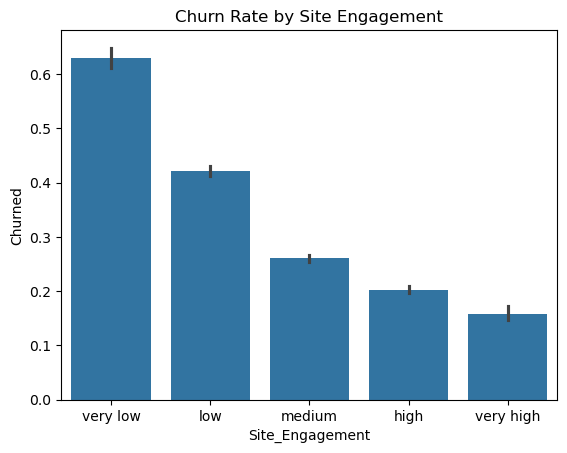

In [211]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(x='Site_Engagement', y='Churned', data=df)
plt.title('Churn Rate by Site Engagement')
plt.show()

### Key Insights

#### 1. Site Engagement vs Churn
- Very low engagement → **63% churn**
- Very high engagement → **15% churn**

 **Insight:**  
Low engagement users are significantly more likely to churn.

 **Conclusion:**  
Engagement is a strong driver of retention.

<Axes: xlabel='Login_Frequency', ylabel='Count'>

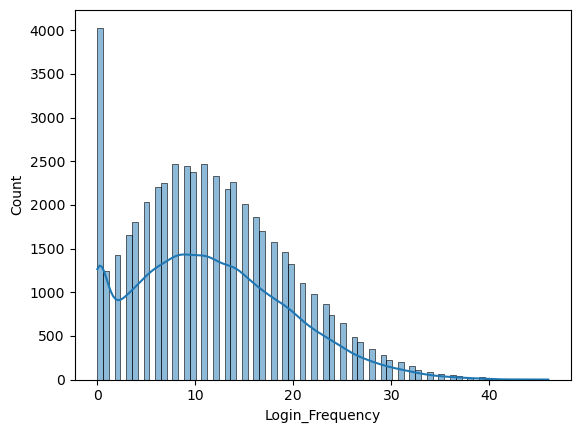

In [212]:
sns.histplot(df['Login_Frequency'], kde=True)


<Axes: xlabel='Login_Frequency', ylabel='Count'>

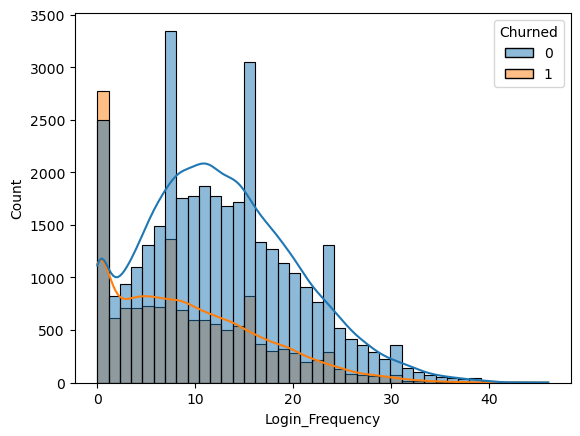

In [213]:
sns.histplot(data=df, x='Login_Frequency', hue='Churned', bins=40, kde=True)

In [214]:
df['login_risk'] = pd.cut(
    df['Login_Frequency'],
    bins=[-1, 5, 10, 20, 50],
    labels=['high risk', 'moderate risk', 'low risk', 'very low risk']
)

In [215]:
df.groupby('login_risk')['Churned'].mean()

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_21272\1173101861.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('login_risk')['Churned'].mean()


login_risk
high risk        0.454434
moderate risk    0.287149
low risk         0.223590
very low risk    0.181422
Name: Churned, dtype: float64

### 2. Login Frequency vs Churn
- Low login users → **~45% churn**
- High login users → **~18% churn**

 **Insight:**  
Users with low login frequency show higher churn probability.

 **Conclusion:**  
Login frequency acts as an early warning signal of churn.

In [216]:
df.groupby('purchase_group')['Churned'].mean()

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_21272\2906636254.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('purchase_group')['Churned'].mean()


purchase_group
very low     0.634850
low          0.281664
medium       0.235803
high         0.217524
very high    0.191919
Name: Churned, dtype: float64

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_21272\968385142.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  churn_rate = df.groupby('purchase_group')['Churned'].mean().reset_index()


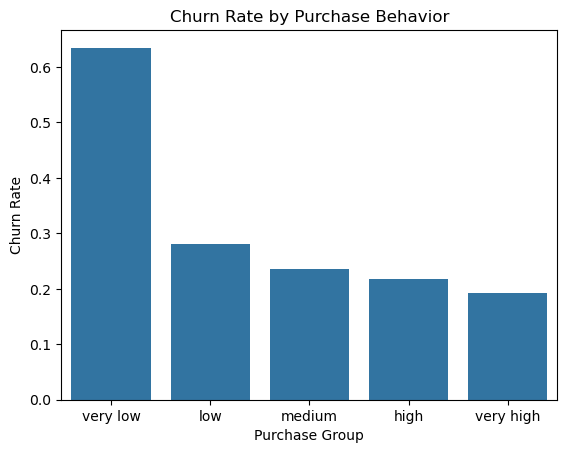

In [217]:
import seaborn as sns
import matplotlib.pyplot as plt

churn_rate = df.groupby('purchase_group')['Churned'].mean().reset_index()

sns.barplot(x='purchase_group', y='Churned', data=churn_rate)
plt.title('Churn Rate by Purchase Behavior')
plt.ylabel('Churn Rate')
plt.xlabel('Purchase Group')
plt.show()

<Axes: xlabel='purchase_group', ylabel='count'>

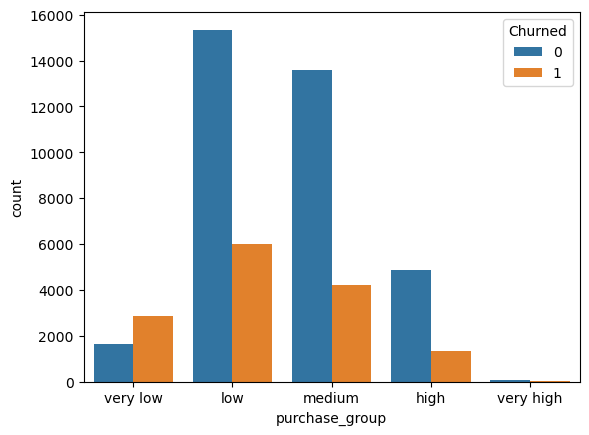

In [218]:
sns.countplot(x='purchase_group', hue='Churned', data=df)

### 3. Purchase Behavior vs Churn
- Very low purchases → **63% churn**
- Very high purchases → **19% churn**

 **Insight:**  
Customers with low transaction activity are highly likely to churn.

 **Conclusion:**  
Higher purchase frequency indicates stronger customer commitment.

In [224]:
df['service_call_group'].value_counts()

service_call_group
high         22507
medium       19765
low           5455
very high     2273
Name: count, dtype: int64

In [226]:
df.groupby('service_call_group')['Churned'].mean()

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_21272\2081450366.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('service_call_group')['Churned'].mean()


service_call_group
low          0.120257
medium       0.160941
high         0.417204
very high    0.538055
Name: Churned, dtype: float64

In [227]:
df.groupby('service_call_group')['Churned'].mean()

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_21272\2081450366.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('service_call_group')['Churned'].mean()


service_call_group
low          0.120257
medium       0.160941
high         0.417204
very high    0.538055
Name: Churned, dtype: float64

### 4.Customer Service Calls vs Churn
- Low calls → **12% churn**
- Very high calls → **53% churn**

 **Insight:**  
Frequent service interactions strongly correlate with churn.

 **Conclusion:**  
Customer dissatisfaction is a major driver of churn.

### Overall Conclusion

Churn is primarily driven by **customer behavior and engagement**, not by tenure.

###  Key Drivers:
- Low site engagement  
- Low login frequency  
- Low purchase activity  
- High customer service interactions  

###  Non-driver:
- Membership duration  


##  Business Recommendations

1. **Improve Engagement**
   - Personalized content
   - Push notifications
   - Better UX

2. **Increase Purchase Activity**
   - Discounts & offers
   - Product recommendations
   - Loyalty programs

3. **Reduce Customer Issues**
   - Faster support resolution
   - Proactive customer service
   - Issue tracking system

4. **Re-engage Low Activity Users**
   - Email campaigns
   - Retargeting strategies
   - Onboarding improvements

In [272]:
df.to_csv('customer_churn_cleaned.csv', index=False)

In [271]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 33 columns):
 #   Column                         Non-Null Count  Dtype   
---  ------                         --------------  -----   
 0   Age                            50000 non-null  float64 
 1   Gender                         50000 non-null  category
 2   Country                        50000 non-null  category
 3   City                           50000 non-null  category
 4   Membership_Years               50000 non-null  float64 
 5   Login_Frequency                50000 non-null  float64 
 6   Session_Duration_Avg           50000 non-null  float64 
 7   Pages_Per_Session              50000 non-null  float64 
 8   Cart_Abandonment_Rate          50000 non-null  float64 
 9   Wishlist_Items                 50000 non-null  float64 
 10  Total_Purchases                50000 non-null  float64 
 11  Average_Order_Value            50000 non-null  float64 
 12  Days_Since_Last_Purchase       5